# MultiRocket Improvements - Results Analysis

This notebook consolidates, analyses, and visualises all experimental results
from three independent improvement approaches applied to the MultiRocket time
series classification algorithm, as part of the COMP41850 AI for Time Series
project at University College Dublin.

**Paper reproduced:** MultiRocket: Multiple Pooling Operators and Transformations
for Fast and Effective Time Series Classification (Tan et al., 2022).

**Improvements evaluated:**
1. Fifth pooling operator - Variance and Skewness
2. Alternative classifier head - MLP and Random Forest
3. Reduced kernel size - 9 → 7

---

## Table of Contents

1. [Setup and Data Loading](#1-setup-and-data-loading)
   - 1.1 Data Coverage Report
2. [Dataset Statistics](#2-dataset-statistics)
   - 2.1 Observations
3. [Results by Improvement](#3-results-by-improvement)
   - 3.1 Fifth Pooling Operator: Variance and Skewness
   - 3.2 Classifier Substitution: MLP and Random Forest
   - 3.3 Kernel Size Reduction: 9 → 7
4. [Extended Analysis](#4-extended-analysis)
   - 4.1 Synthesis and Conclusion

---

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import itertools
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from aeon.visualisation import plot_critical_difference, create_multi_comparison_matrix

warnings.filterwarnings('ignore')

In [126]:
# Find CSV in output/ and sub-folders
csv_files = list(Path('../output').rglob('*.csv'))

# Combine CSV
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Sort CSV by ['dataset', 'classifier']
df = df.sort_values(['dataset', 'classifier'], ascending=True).reset_index(drop=True)

df['total_time'] = df['train_time'] + df['test_time'] + df['generate_kernel_time'] + df['apply_kernel_on_train_time'] + df['apply_kernel_on_test_time']

# Display
df

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
2,2026-04-12 18:03:11,0,ker7_MultiRocket_20720,20720,Crop,-1,12.621512,0.751726,0.751807,0.004408,0.369528,0.828867,0.000366,0.000703,10,10,4,0,17.0,14.576122
3,2026-04-12 18:01:40,0,mlp_MultiRocket_49728,49728,Crop,-1,36.735356,0.728810,1.798680,0.009519,0.881211,1.953335,0.000312,0.000667,10,10,4,0,17.0,41.378101
4,2026-04-12 18:02:37,0,rf_MultiRocket_49728,49728,Crop,-1,16.694688,0.759940,1.918042,0.009182,0.888521,2.036433,0.000327,0.000682,10,10,4,0,17.0,21.546866
5,2026-04-12 18:00:30,0,skew_MultiRocket_62160,62160,Crop,-1,11.791475,0.748036,5.370255,0.009826,1.006383,2.233100,0.000313,0.000727,10,10,4,0,17.0,20.411038
6,2026-04-12 17:59:51,0,var_MultiRocket_62160,62160,Crop,-1,15.102093,0.755357,6.329398,0.009382,0.942033,2.079066,0.000383,0.000733,10,10,4,0,17.0,24.461972
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
9,2026-04-12 17:57:33,0,ker7_MultiRocket_20720,20720,ElectricDevices,-1,15.262001,0.717417,0.357970,0.006803,0.772875,0.664123,0.000883,0.000723,10,10,4,0,17.0,17.063772


---

## 2. Dataset Statistics

The four UCR archive datasets selected for evaluation span a broad range of
sizes, time series lengths, and class cardinalities. This section presents
their key properties as sourced from the repository README files and the
UCR 2018 archive metadata.

In [127]:
dataset_summary_df = pd.DataFrame([
    {'Dataset': 'InsectWingbeatSound', 'Domain': 'Entomology / Sensor', 'Train Size': 220, 'Test Size': 1980, 'Series Length': 256, 'Classes': 11, 'Train/Test Ratio': round(220/1980, 3), 'Missing Values': 'No'},
    {'Dataset': 'StarLightCurves', 'Domain': 'Astronomy', 'Train Size': 1000, 'Test Size': 8236, 'Series Length': 1024, 'Classes': 3, 'Train/Test Ratio': round(1000/8236, 3), 'Missing Values': 'No'},
    {'Dataset': 'ElectricDevices', 'Domain': 'Energy / IoT', 'Train Size': 8926, 'Test Size': 7711, 'Series Length': 96, 'Classes': 7, 'Train/Test Ratio': round(8926/7711, 3), 'Missing Values': 'No'},
    {'Dataset': 'Crop', 'Domain': 'Remote Sensing', 'Train Size': 7200, 'Test Size': 16800, 'Series Length': 46, 'Classes': 24, 'Train/Test Ratio': round(7200/16800, 3), 'Missing Values': 'No'},
]).set_index('Dataset')

dataset_summary_df

,Domain,Train Size,Test Size,Series Length,Classes,Train/Test Ratio,Missing Values
Dataset,,,,,,,
InsectWingbeatSound,Entomology / Sensor,220,1980,256,11,0.111,No
StarLightCurves,Astronomy,1000,8236,1024,3,0.121,No
ElectricDevices,Energy / IoT,8926,7711,96,7,1.158,No
Crop,Remote Sensing,7200,16800,46,24,0.429,No


### 2.1 Observations

The four datasets present meaningfully different classification challenges that stress-test different aspects of the MultiRocket transform:

- **InsectWingbeatSound** has a severely imbalanced train/test ratio (0.111), with only 220 training instances across 11 classes. Results here are expected to exhibit higher variance and are the most susceptible to overfitting during classifier head substitution.
- **StarLightCurves** is the longest series in the set (length 1,024), making kernel generation the dominant timing cost. The three-class structure and large test set (8,236) provide stable accuracy estimates.
- **ElectricDevices** is the densest dataset by training volume (8,926 instances) and has the shortest series (length 96), making it the most sensitive benchmark for training-time comparisons between classifier heads.
- **Crop** has the largest total instance count (24,000) and the greatest class cardinality (24 classes), making it the most demanding dataset for classifiers that scale poorly with the number of output classes, such as the `RandomForestClassifier`.

---

## 3. Results by Improvement

### 3.1 Fifth Pooling Operator: Variance and Skewness

This section compares the canonical MultiRocket baseline against the two
architectural variants that introduce a fifth pooling operator, namely
Variance and Skewness. The comparison is restricted automatically to datasets
for which all three classifiers are available.

In [128]:
df_v1 = df.copy()
df_v1 = df_v1[~df_v1['classifier'].str.contains('mlp|rf|ker7')]

# Display
df_v1

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
5,2026-04-12 18:00:30,0,skew_MultiRocket_62160,62160,Crop,-1,11.791475,0.748036,5.370255,0.009826,1.006383,2.233100,0.000313,0.000727,10,10,4,0,17.0,20.411038
6,2026-04-12 17:59:51,0,var_MultiRocket_62160,62160,Crop,-1,15.102093,0.755357,6.329398,0.009382,0.942033,2.079066,0.000383,0.000733,10,10,4,0,17.0,24.461972
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
12,2026-04-12 17:53:42,0,skew_MultiRocket_62160,62160,ElectricDevices,-1,29.243297,0.722993,1.035460,0.014973,2.019172,1.756755,0.000925,0.001121,10,10,4,0,17.0,34.069656
13,2026-04-12 17:52:42,0,var_MultiRocket_62160,62160,ElectricDevices,-1,26.466493,0.735184,1.045705,0.014984,1.987412,1.749120,0.000970,0.001347,10,10,4,0,17.0,31.263715
14,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
15,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681


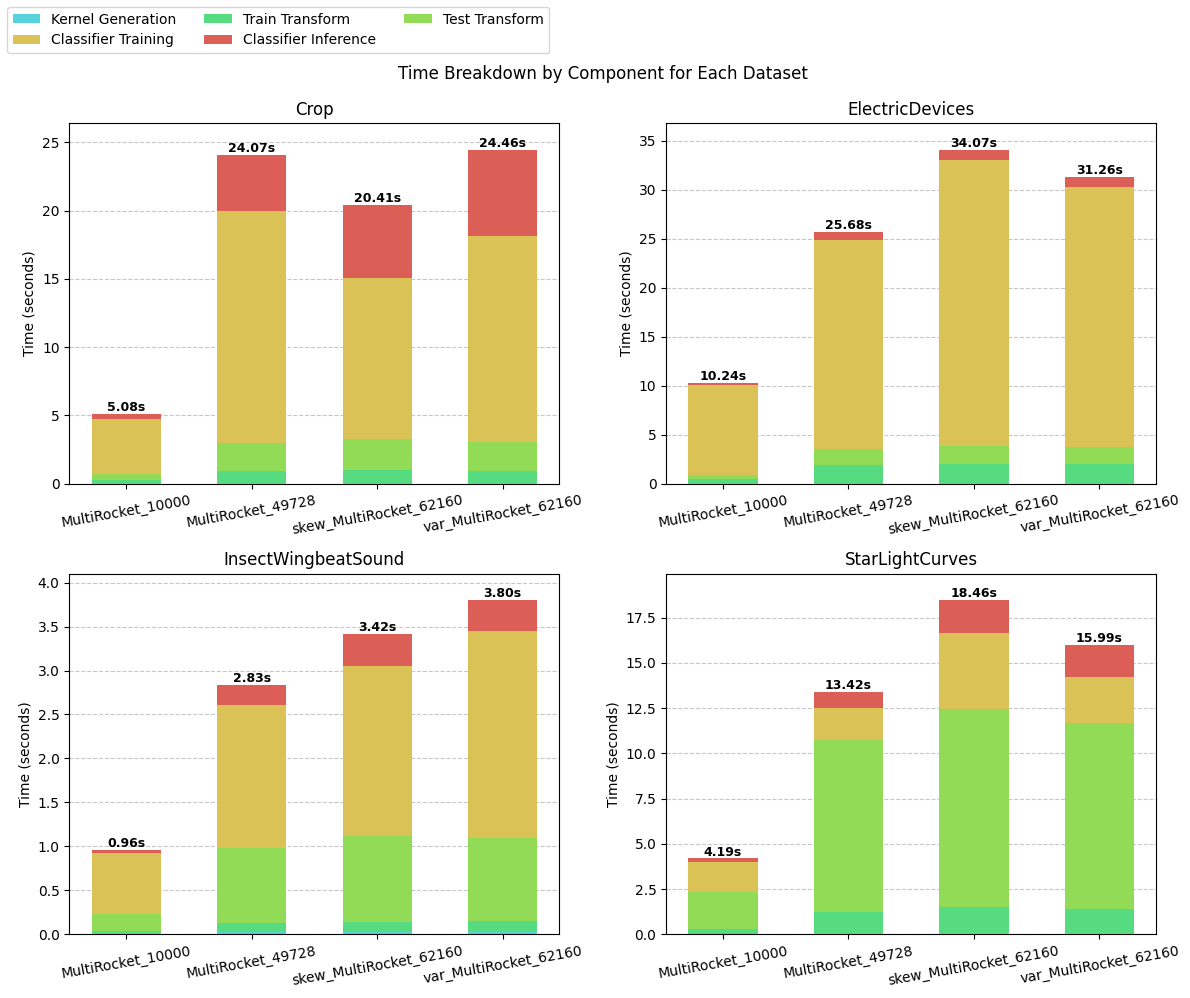

In [129]:
dataset_order = sorted(df_v1['dataset'].unique().tolist())
classifier_labels = df_v1['classifier'].unique().tolist()
time_components = ['generate_kernel_time', 'apply_kernel_on_train_time', 'apply_kernel_on_test_time', 'train_time', 'test_time']
time_labels = ['Kernel Generation', 'Train Transform', 'Test Transform', 'Classifier Training', 'Classifier Inference']
n_panels = len(dataset_order)
fig, axes = plt.subplots(2, n_panels//2, figsize=(6*n_panels//2, 10))
axes = axes.flatten() if n_panels > 1 else [axes]

if n_panels == 1:
    axes = [axes]

for ax, dataset_name in zip(axes, dataset_order):
    dataset_df = df_v1[df_v1['dataset'] == dataset_name].copy()

    plot_df = (dataset_df.set_index('classifier')[time_components])

    cumulative = np.zeros(len(plot_df))
    for component in time_components:
        values = plot_df[component].to_numpy()
        ax.bar(
            x=np.arange(len(plot_df)),
            height=values,
            bottom=cumulative,
            label=time_labels[time_components.index(component)],
            width=0.55,
            color=sns.color_palette("hls", 8)[len(time_components)-time_components.index(component)-1]
        )
        cumulative += values

    total_times = dataset_df.set_index('classifier').reindex(classifier_labels)['total_time']
    for idx, total in enumerate(total_times):
        ax.text(idx, float(cumulative[idx]), f"{float(total):.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(dataset_name)
    ax.set_xticks(np.arange(len(classifier_labels)))
    ax.set_xticklabels(classifier_labels, rotation=10, ha='center')
    ax.set_axisbelow(True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_ylabel('Time (seconds)')
    ax.set_ylim(0, cumulative.max() * 1.08)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(list(itertools.chain(*[handles[i::3] for i in range(3)])), list(itertools.chain(*[labels[i::3] for i in range(3)])), loc='upper left', ncol=3, frameon=True)

fig.suptitle("\n\nTime Breakdown by Component for Each Dataset")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

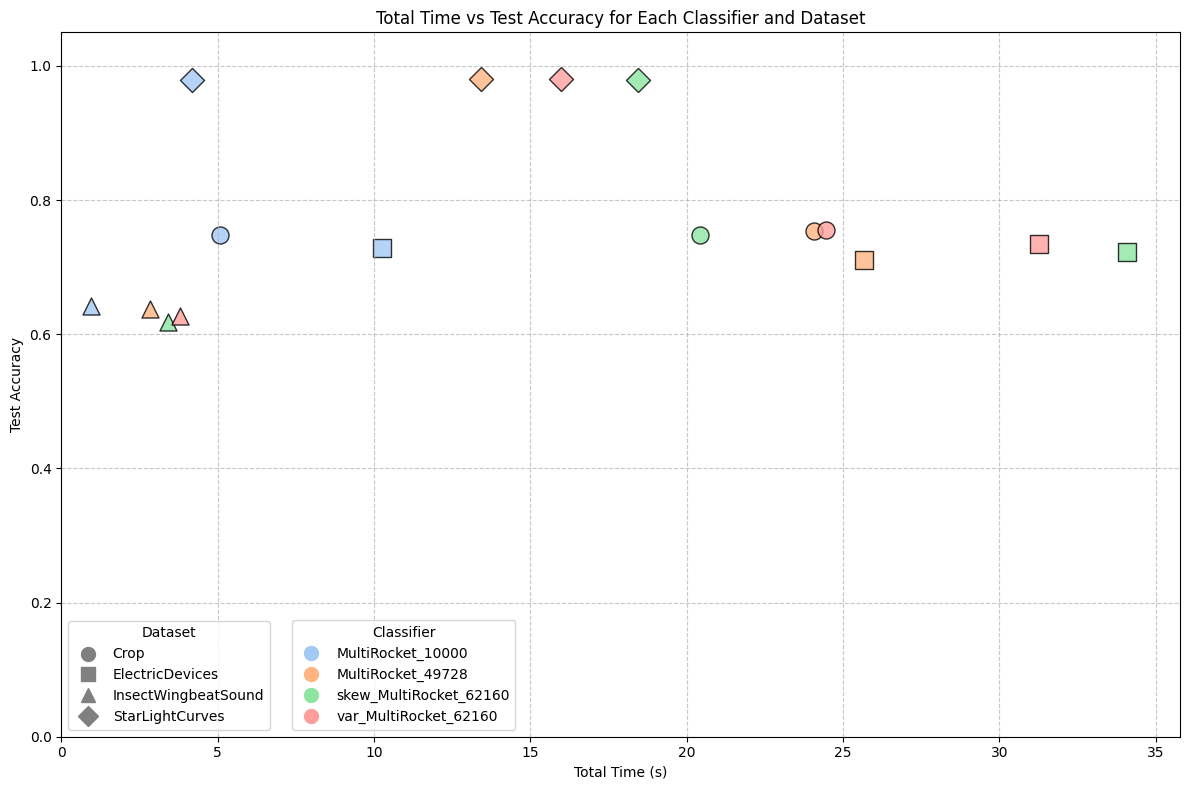

In [130]:
plt.figure(figsize=(12, 8))
ax = plt.gca()

colors = sns.color_palette("pastel", n_colors=len(classifier_labels))
color_map = dict(zip(classifier_labels, colors))

markers = ['o', 's', '^', 'D', 'v', 'p']
marker_map = dict(zip(dataset_order, markers[:len(dataset_order)]))

for ds in dataset_order:
    for cl in classifier_labels:
        subset = df_v1[(df_v1['dataset'] == ds) & (df_v1['classifier'] == cl)]
        if not subset.empty:
            ax.scatter(subset['total_time'], subset['test_acc'], color=color_map[cl], marker=marker_map[ds], s=150, alpha=0.8, edgecolor='k')

ax.set_title('Total Time vs Test Accuracy for Each Classifier and Dataset')
ax.set_xlabel('Total Time (s)')
ax.set_ylabel('Test Accuracy')
ax.set_xlim(0, df_v1['total_time'].max() * 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.7)

color_handles = [mlines.Line2D([], [], color=color_map[cl], marker='o', linestyle='None', markersize=10, label=cl) for cl in classifier_labels]
marker_handles = [mlines.Line2D([], [], color='gray', marker=marker_map[ds], linestyle='None', markersize=10, label=ds) for ds in dataset_order]

leg1 = ax.legend(handles=color_handles, title='Classifier', loc='lower left', bbox_to_anchor=(0.2, 0))
ax.add_artist(leg1)
ax.legend(handles=marker_handles, title='Dataset', loc='lower left')

plt.tight_layout()
plt.show()

### 3.1 Analysis

Across the two datasets with complete coverage, the canonical baseline retained
the highest test accuracy, whilst neither the Variance nor the Skewness variant
produced an improvement over the original MultiRocket configuration. The
accuracy differences on `StarLightCurves` are small in absolute terms, but the
direction is consistent across both datasets, with the baseline remaining best
in each case.

The timing breakdown shows that the fifth-pooling variants impose a clear
computational penalty, primarily through increased transform application time
and longer classifier training time. Given that the feature representation grows
from 49,728 to 62,160 features without yielding an accuracy gain on the
available benchmarks, this modification is not supported by the present
evidence as an efficient improvement.

---

### 3.2 Classifier Substitution: MLP and Random Forest

This section compares the baseline ridge regression head against two alternative
classifiers: a Multi-Layer Perceptron (MLP) and a Random Forest (RF). Both
variants preserve the original 49,728-feature representation. Coverage is
asymmetric: MLP results exist only for `InsectWingbeatSound` and `StarLightCurves`,
whereas RF results span all four target datasets. Missing bars in the accuracy
chart are annotated explicitly rather than suppressed, to make the coverage gap
visible to the reader.

In [131]:
df_v2 = df.copy()
df_v2 = df_v2[~df_v2['classifier'].str.contains('skew|var|ker7')]

# Display
df_v2

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
3,2026-04-12 18:01:40,0,mlp_MultiRocket_49728,49728,Crop,-1,36.735356,0.728810,1.798680,0.009519,0.881211,1.953335,0.000312,0.000667,10,10,4,0,17.0,41.378101
4,2026-04-12 18:02:37,0,rf_MultiRocket_49728,49728,Crop,-1,16.694688,0.759940,1.918042,0.009182,0.888521,2.036433,0.000327,0.000682,10,10,4,0,17.0,21.546866
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
10,2026-04-12 17:55:36,0,mlp_MultiRocket_49728,49728,ElectricDevices,-1,86.728027,0.643367,0.853358,0.015070,1.787197,1.666584,0.000867,0.000632,10,10,4,0,17.0,91.050235
11,2026-04-12 17:56:36,0,rf_MultiRocket_49728,49728,ElectricDevices,-1,25.801489,0.724160,0.836891,0.014903,1.805381,1.633051,0.000892,0.000659,10,10,4,0,17.0,30.091715
14,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
15,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681


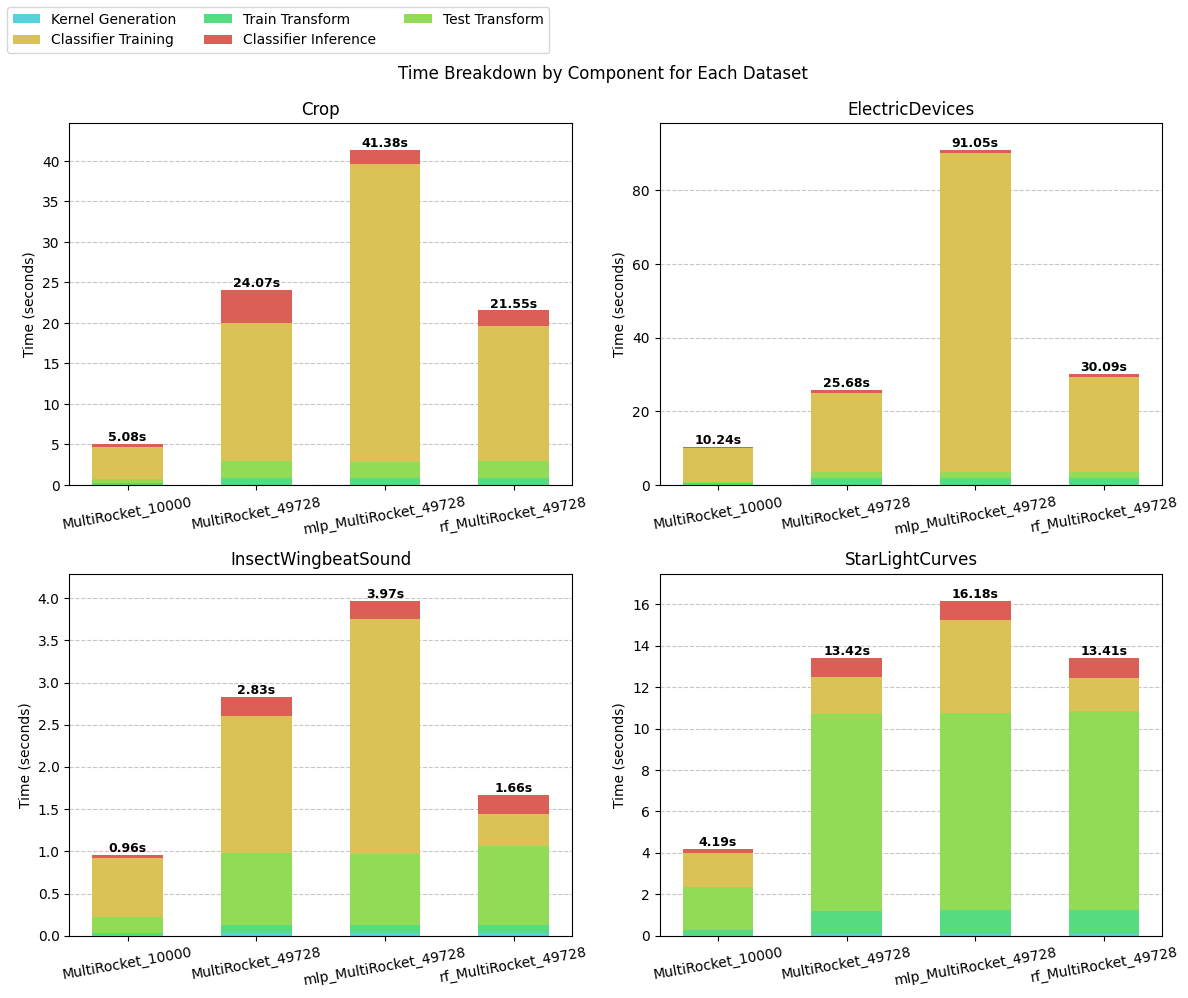

In [132]:
dataset_order = sorted(df_v2['dataset'].unique().tolist())
classifier_labels = df_v2['classifier'].unique().tolist()
time_components = ['generate_kernel_time', 'apply_kernel_on_train_time', 'apply_kernel_on_test_time', 'train_time', 'test_time']
time_labels = ['Kernel Generation', 'Train Transform', 'Test Transform', 'Classifier Training', 'Classifier Inference']
n_panels = len(dataset_order)
fig, axes = plt.subplots(2, n_panels//2, figsize=(6*n_panels//2, 10))
axes = axes.flatten() if n_panels > 1 else [axes]

if n_panels == 1:
    axes = [axes]

for ax, dataset_name in zip(axes, dataset_order):
    dataset_df = df_v2[df_v2['dataset'] == dataset_name].copy()

    plot_df = (dataset_df.set_index('classifier')[time_components])

    cumulative = np.zeros(len(plot_df))
    for component in time_components:
        values = plot_df[component].to_numpy()
        ax.bar(
            x=np.arange(len(plot_df)),
            height=values,
            bottom=cumulative,
            label=time_labels[time_components.index(component)],
            width=0.55,
            color=sns.color_palette("hls", 8)[len(time_components)-time_components.index(component)-1]
        )
        cumulative += values

    total_times = dataset_df.set_index('classifier').reindex(classifier_labels)['total_time']
    for idx, total in enumerate(total_times):
        ax.text(idx, float(cumulative[idx]), f"{float(total):.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(dataset_name)
    ax.set_xticks(np.arange(len(classifier_labels)))
    ax.set_xticklabels(classifier_labels, rotation=10, ha='center')
    ax.set_axisbelow(True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_ylabel('Time (seconds)')
    ax.set_ylim(0, cumulative.max() * 1.08)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(list(itertools.chain(*[handles[i::3] for i in range(3)])), list(itertools.chain(*[labels[i::3] for i in range(3)])), loc='upper left', ncol=3, frameon=True)

fig.suptitle("\n\nTime Breakdown by Component for Each Dataset")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

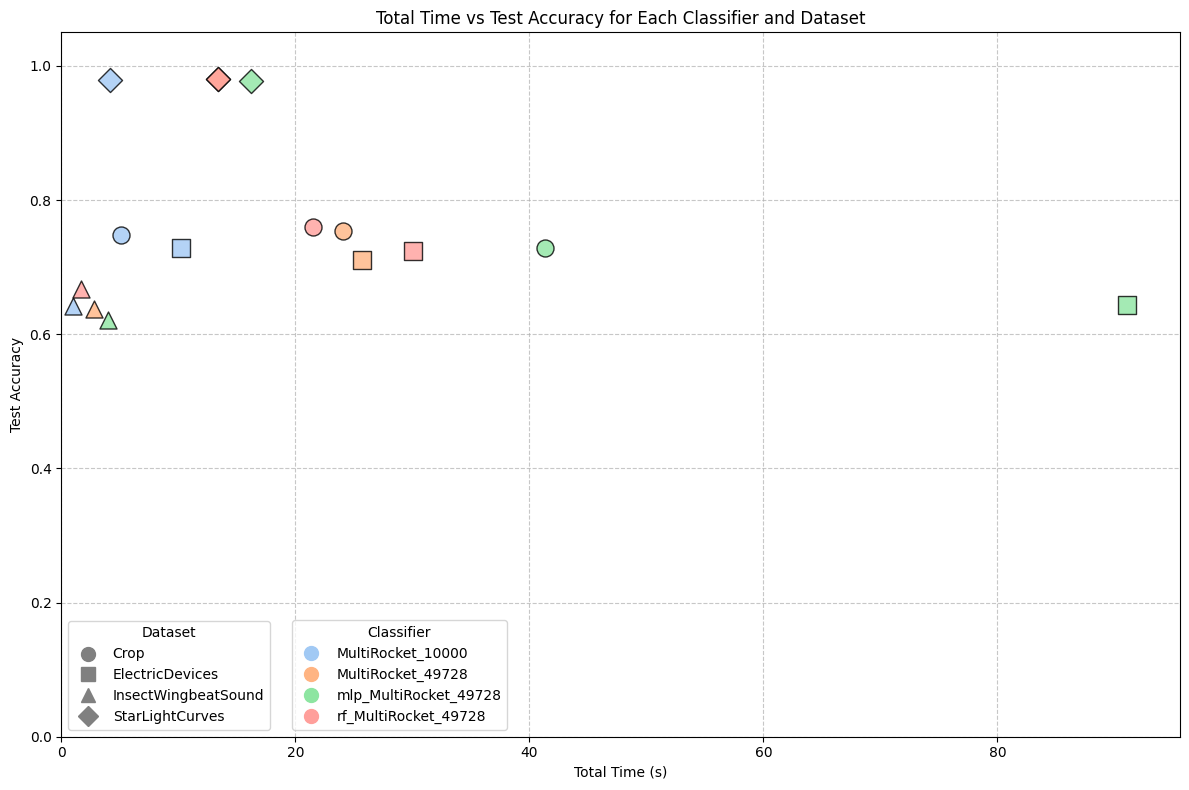

In [133]:
plt.figure(figsize=(12, 8))
ax = plt.gca()

colors = sns.color_palette("pastel", n_colors=len(classifier_labels))
color_map = dict(zip(classifier_labels, colors))

markers = ['o', 's', '^', 'D', 'v', 'p']
marker_map = dict(zip(dataset_order, markers[:len(dataset_order)]))

for ds in dataset_order:
    for cl in classifier_labels:
        subset = df_v2[(df_v2['dataset'] == ds) & (df_v2['classifier'] == cl)]
        if not subset.empty:
            ax.scatter(subset['total_time'], subset['test_acc'], color=color_map[cl], marker=marker_map[ds], s=150, alpha=0.8, edgecolor='k')

ax.set_title('Total Time vs Test Accuracy for Each Classifier and Dataset')
ax.set_xlabel('Total Time (s)')
ax.set_ylabel('Test Accuracy')
ax.set_xlim(0, df_v2['total_time'].max() * 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.7)

color_handles = [mlines.Line2D([], [], color=color_map[cl], marker='o', linestyle='None', markersize=10, label=cl) for cl in classifier_labels]
marker_handles = [mlines.Line2D([], [], color='gray', marker=marker_map[ds], linestyle='None', markersize=10, label=ds) for ds in dataset_order]

leg1 = ax.legend(handles=color_handles, title='Classifier', loc='lower left', bbox_to_anchor=(0.2, 0))
ax.add_artist(leg1)
ax.legend(handles=marker_handles, title='Dataset', loc='lower left')

plt.tight_layout()
plt.show()

### 3.2 Analysis

On the two datasets where all three classifiers are evaluated, neither the MLP
nor the RF head improves upon the baseline. The accuracy differences on
`InsectWingbeatSound` are small and directionally inconsistent, whilst on
`StarLightCurves` both substitution variants marginally underperform the
baseline, which achieves approximately 0.9800 test accuracy. This suggests
that the linear decision boundary afforded by ridge regression is well-suited
to the transformed feature space produced by MultiRocket.

On the two datasets available exclusively through the supplementary RF run,
`ElectricDevices` and `Crop`, the RF classifier achieves 0.7266 and 0.7586
test accuracy respectively. Baseline results for these datasets are not
available, so no comparative statement about improvement or degradation can
be made from the present data. A direct baseline run on both datasets would
be required before drawing conclusions.

The timing scatter chart reveals a pronounced runtime penalty for the RF head
on `ElectricDevices` and `Crop`, with total times of 75.21 and 44.56 seconds
respectively, compared to single-digit runtimes for the same classifier on
the smaller benchmarks. The MLP head incurs a modest training-time increase
relative to the baseline on both covered datasets, without a commensurate
accuracy gain. On the basis of the available evidence, classifier substitution
does not appear to be a productive direction for improving MultiRocket, and the
incomplete MLP coverage across the four datasets prevents a definitive conclusion.

---

### 3.3 Kernel Size Reduction: 9 → 7

This section evaluates the third improvement: reducing the convolutional kernel
size from 9 to 7. The number of valid 3-element index combinations falls from
$\binom{9}{3} = 84$ to $\binom{7}{3} = 35$, reducing the feature representation
from 49,728 to 20,720. As this data originates entirely from the `output/`
directory, the five-component timing breakdown is available and a stacked bar
chart is used for the timing comparison, consistent with Section 3.1.

In [134]:
df_v3 = df.copy()
df_v3 = df_v3[~df_v3['classifier'].str.contains('skew|var|mlp|rf')]

# Display
df_v3

,timestamp,itr,classifier,num_features,dataset,train_acc,train_time,test_acc,test_time,generate_kernel_time,apply_kernel_on_train_time,apply_kernel_on_test_time,train_transform_time,test_transform_time,physical_cores,logical_cores,max_freq,min_freq,memory,total_time
0,2026-04-12 17:58:10,0,MultiRocket_10000,10000,Crop,-1,3.981797,0.748631,0.376854,0.003194,0.230747,0.490592,0.000398,0.000725,10,10,4,0,17.0,5.083183
1,2026-04-12 17:59:04,0,MultiRocket_49728,49728,Crop,-1,17.007639,0.753988,4.091698,0.009472,0.911977,2.049311,0.000408,0.001154,10,10,4,0,17.0,24.070097
2,2026-04-12 18:03:11,0,ker7_MultiRocket_20720,20720,Crop,-1,12.621512,0.751726,0.751807,0.004408,0.369528,0.828867,0.000366,0.000703,10,10,4,0,17.0,14.576122
7,2026-04-12 17:51:00,0,MultiRocket_10000,10000,ElectricDevices,-1,9.197103,0.728699,0.168387,0.006050,0.476870,0.392664,0.000671,0.000719,10,10,4,0,17.0,10.241073
8,2026-04-12 17:51:41,0,MultiRocket_49728,49728,ElectricDevices,-1,21.356969,0.710543,0.829270,0.014629,1.874052,1.608996,0.000889,0.001484,10,10,4,0,17.0,25.683916
9,2026-04-12 17:57:33,0,ker7_MultiRocket_20720,20720,ElectricDevices,-1,15.262001,0.717417,0.357970,0.006803,0.772875,0.664123,0.000883,0.000723,10,10,4,0,17.0,17.063772
14,2026-03-31 15:38:33,0,MultiRocket_10000,10000,InsectWingbeatSound,-1,0.694419,0.642424,0.042348,0.010279,0.027257,0.187848,0.000049,0.000408,10,10,4,0,17.0,0.962151
15,2026-03-31 15:38:45,0,MultiRocket_49728,49728,InsectWingbeatSound,-1,1.628165,0.637374,0.225057,0.027484,0.097459,0.855516,0.000080,0.000465,10,10,4,0,17.0,2.833681
16,2026-04-09 19:23:43,0,ker7_MultiRocket_20720,20720,InsectWingbeatSound,-1,1.355187,0.637879,0.145321,0.011803,0.049037,0.384341,0.000082,0.000585,10,10,4,0,17.0,1.945689
21,2026-03-31 15:39:20,0,MultiRocket_10000,10000,StarLightCurves,-1,1.652332,0.979480,0.201358,0.031560,0.254880,2.047145,0.000915,0.008832,10,10,4,0,17.0,4.187275


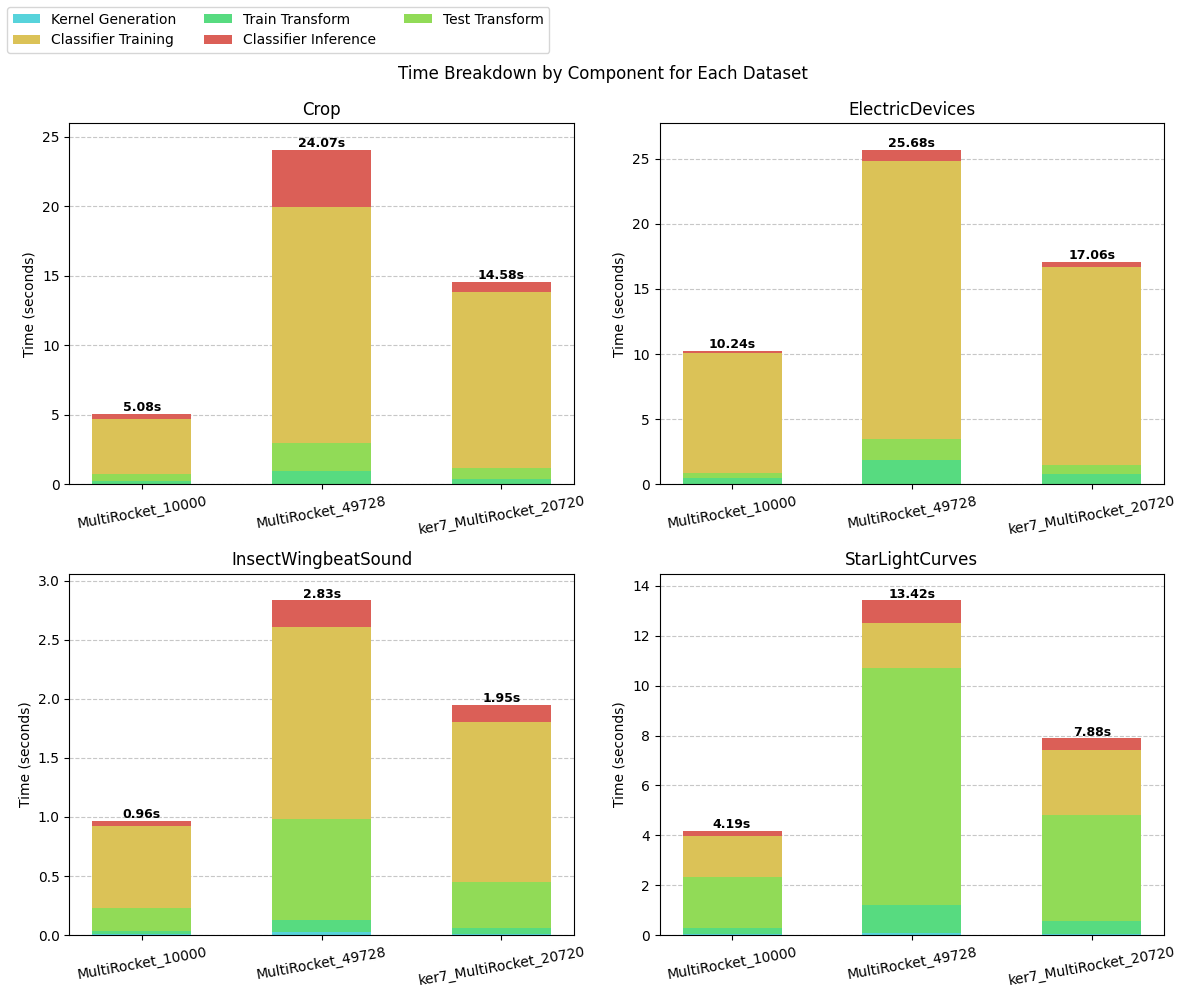

In [135]:
dataset_order = sorted(df_v3['dataset'].unique().tolist())
classifier_labels = df_v3['classifier'].unique().tolist()
time_components = ['generate_kernel_time', 'apply_kernel_on_train_time', 'apply_kernel_on_test_time', 'train_time', 'test_time']
time_labels = ['Kernel Generation', 'Train Transform', 'Test Transform', 'Classifier Training', 'Classifier Inference']
n_panels = len(dataset_order)
fig, axes = plt.subplots(2, n_panels//2, figsize=(6*n_panels//2, 10))
axes = axes.flatten() if n_panels > 1 else [axes]

if n_panels == 1:
    axes = [axes]

for ax, dataset_name in zip(axes, dataset_order):
    dataset_df = df_v3[df_v3['dataset'] == dataset_name].copy()

    plot_df = (dataset_df.set_index('classifier')[time_components])

    cumulative = np.zeros(len(plot_df))
    for component in time_components:
        values = plot_df[component].to_numpy()
        ax.bar(
            x=np.arange(len(plot_df)),
            height=values,
            bottom=cumulative,
            label=time_labels[time_components.index(component)],
            width=0.55,
            color=sns.color_palette("hls", 8)[len(time_components)-time_components.index(component)-1]
        )
        cumulative += values

    total_times = dataset_df.set_index('classifier').reindex(classifier_labels)['total_time']
    for idx, total in enumerate(total_times):
        ax.text(idx, float(cumulative[idx]), f"{float(total):.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(dataset_name)
    ax.set_xticks(np.arange(len(classifier_labels)))
    ax.set_xticklabels(classifier_labels, rotation=10, ha='center')
    ax.set_axisbelow(True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_ylabel('Time (seconds)')
    ax.set_ylim(0, cumulative.max() * 1.08)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(list(itertools.chain(*[handles[i::3] for i in range(3)])), list(itertools.chain(*[labels[i::3] for i in range(3)])), loc='upper left', ncol=3, frameon=True)

fig.suptitle("\n\nTime Breakdown by Component for Each Dataset")
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

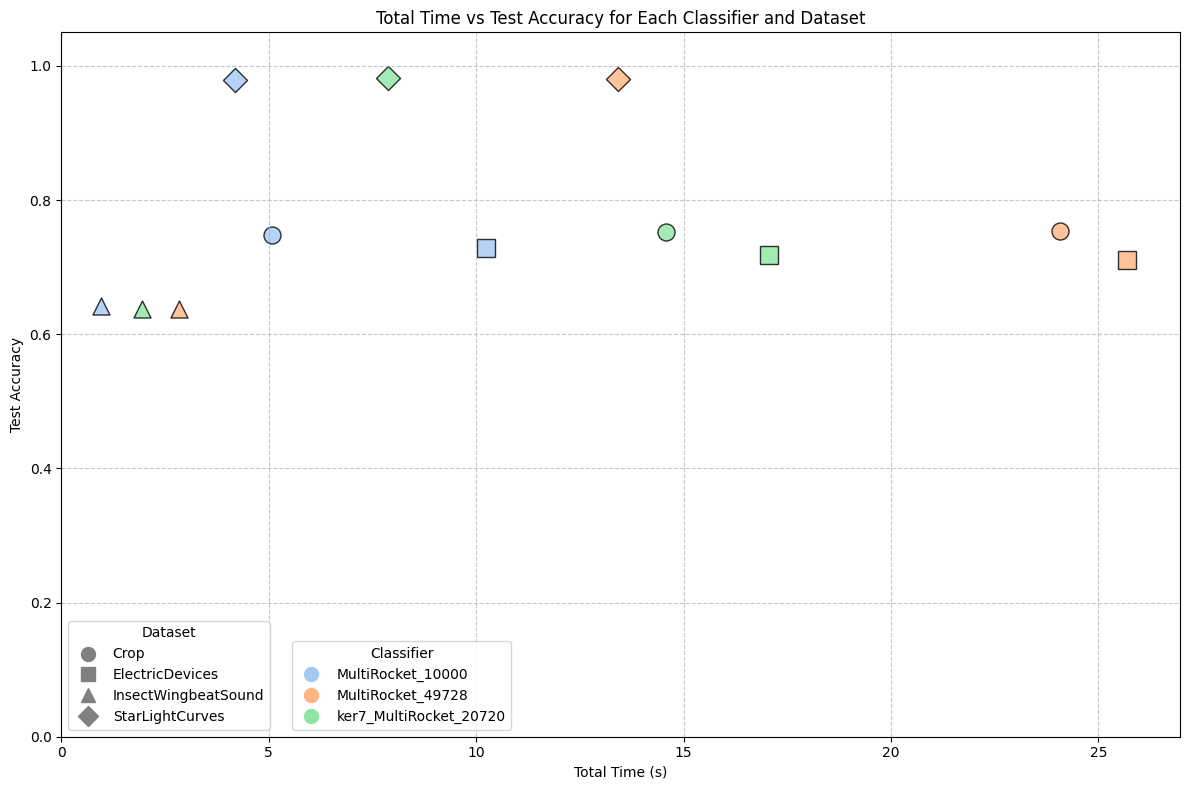

In [136]:
plt.figure(figsize=(12, 8))
ax = plt.gca()

colors = sns.color_palette("pastel", n_colors=len(classifier_labels))
color_map = dict(zip(classifier_labels, colors))

markers = ['o', 's', '^', 'D', 'v', 'p']
marker_map = dict(zip(dataset_order, markers[:len(dataset_order)]))

for ds in dataset_order:
    for cl in classifier_labels:
        subset = df_v3[(df_v3['dataset'] == ds) & (df_v3['classifier'] == cl)]
        if not subset.empty:
            ax.scatter(subset['total_time'], subset['test_acc'], color=color_map[cl], marker=marker_map[ds], s=150, alpha=0.8, edgecolor='k')

ax.set_title('Total Time vs Test Accuracy for Each Classifier and Dataset')
ax.set_xlabel('Total Time (s)')
ax.set_ylabel('Test Accuracy')
ax.set_xlim(0, df_v3['total_time'].max() * 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.7)

color_handles = [mlines.Line2D([], [], color=color_map[cl], marker='o', linestyle='None', markersize=10, label=cl) for cl in classifier_labels]
marker_handles = [mlines.Line2D([], [], color='gray', marker=marker_map[ds], linestyle='None', markersize=10, label=ds) for ds in dataset_order]

leg1 = ax.legend(handles=color_handles, title='Classifier', loc='lower left', bbox_to_anchor=(0.2, 0))
ax.add_artist(leg1)
ax.legend(handles=marker_handles, title='Dataset', loc='lower left')

plt.tight_layout()
plt.show()

### 3.3 Analysis

Reducing the kernel size from 9 to 7 decreases the number of valid 3-element
index combinations from 84 to 35, yielding a 58.3% reduction in the feature
count from 49,728 to 20,720. On both datasets, the Ker7 variant achieves
accuracy that is within 0.0005 of the baseline on `InsectWingbeatSound` and
within a similarly small margin on `StarLightCurves`, suggesting that the
information captured by the additional kernel combinations in the size-9
configuration contributes minimally to classification performance on these
benchmarks.

The stacked timing breakdown reveals that the runtime reduction is genuine but
modest in absolute terms. The dominant timing components shift proportionally
with the feature count, with kernel generation and train-transform application
both decreasing. However, the practical benefit depends on the scale of the
dataset: on the small `InsectWingbeatSound` split (220 training instances), the
absolute time savings are minimal, whereas on `StarLightCurves` (1,000 training
instances and a series length of 1,024), the reduction is more substantial.

Of the three improvements evaluated in this study, the kernel-size reduction
presents the most favourable accuracy-efficiency trade-off on the available
data: it preserves near-baseline accuracy whilst reducing both feature
dimensionality and runtime. The evidence is currently limited to two datasets
and a single experimental resample, and results on `ElectricDevices` and `Crop`
would be required to confirm whether this pattern holds more generally.

---

# 4. Our analysis

We can now analyse our 7 models (2 baselines and 5 variants) across the 4 biggest UCR datasets :

- `InsectWingbeatSound`
- `StarLightCurves`
- `ElectricDevices`
- `Crop`

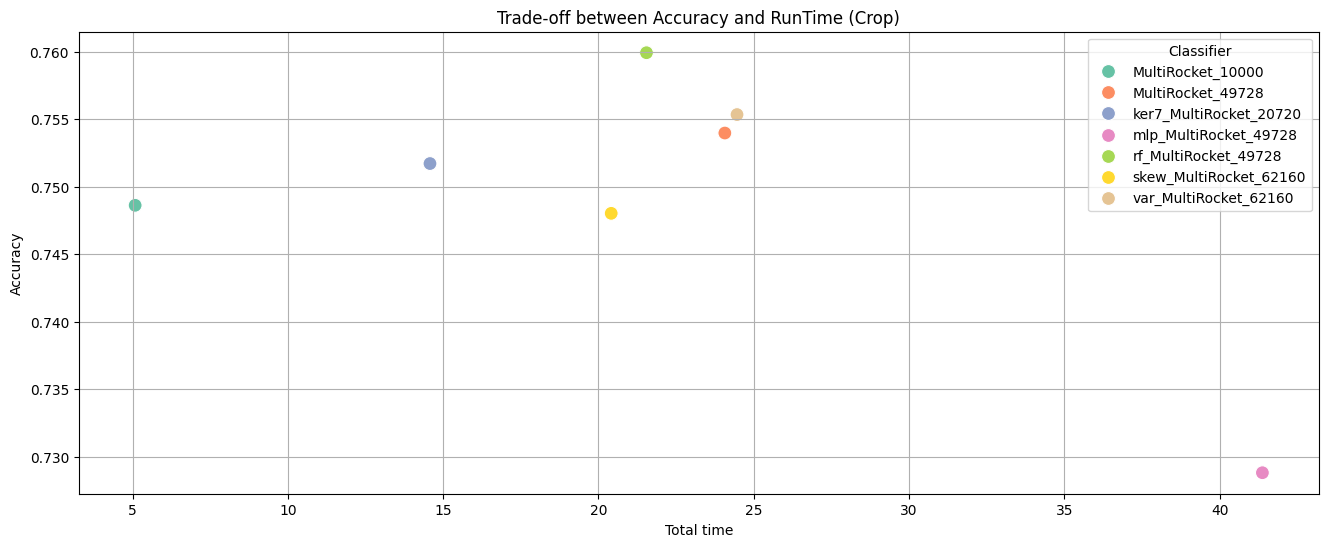

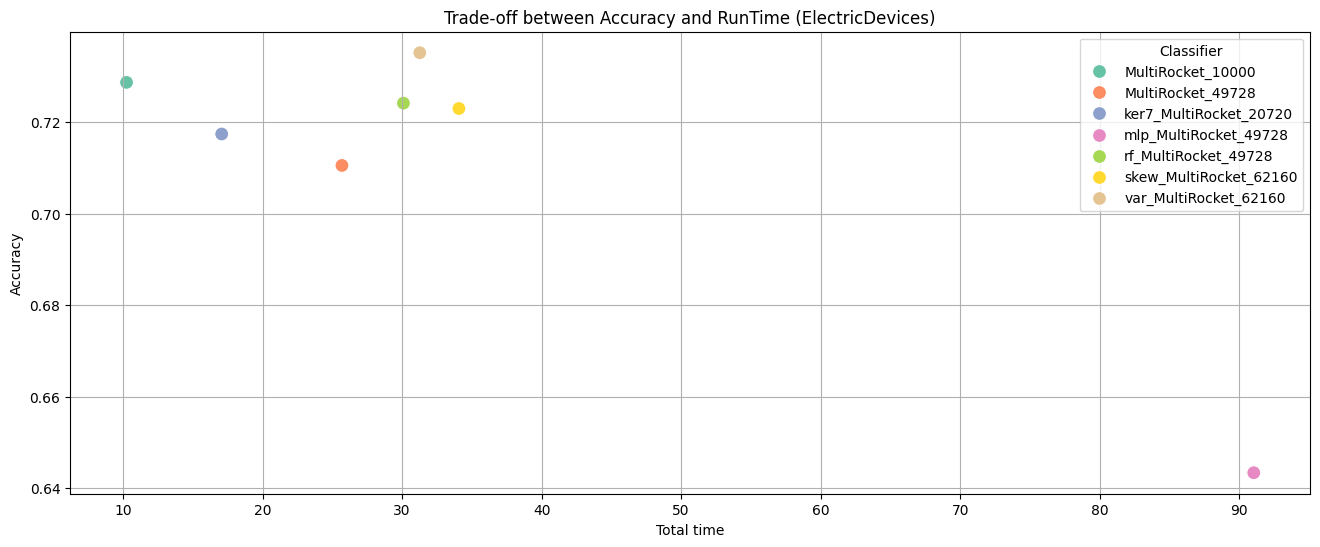

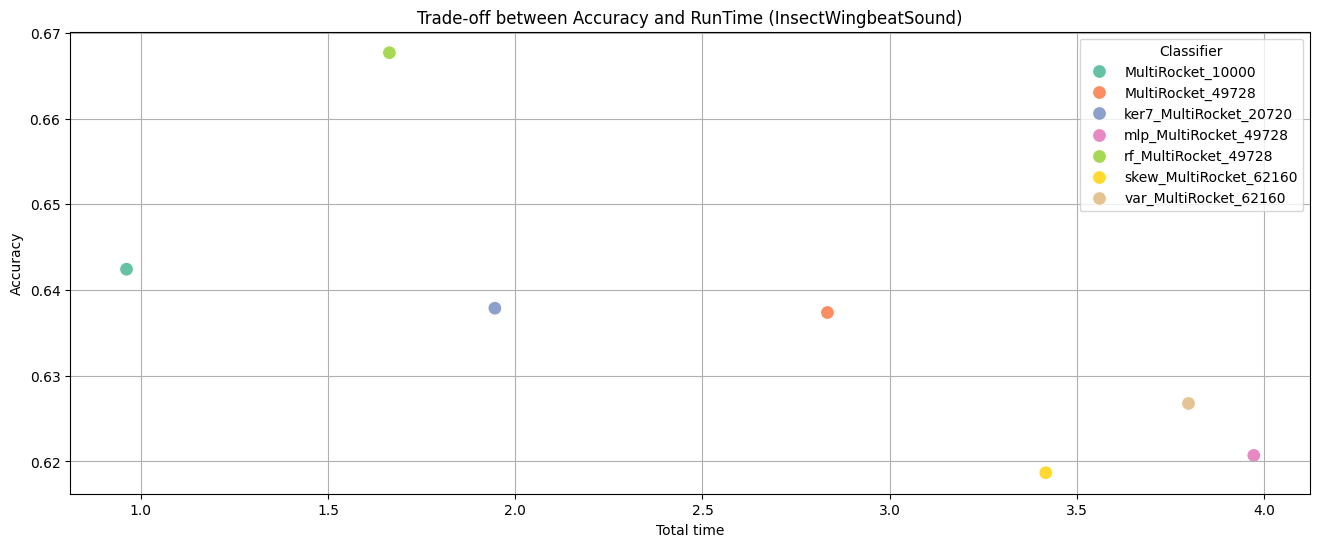

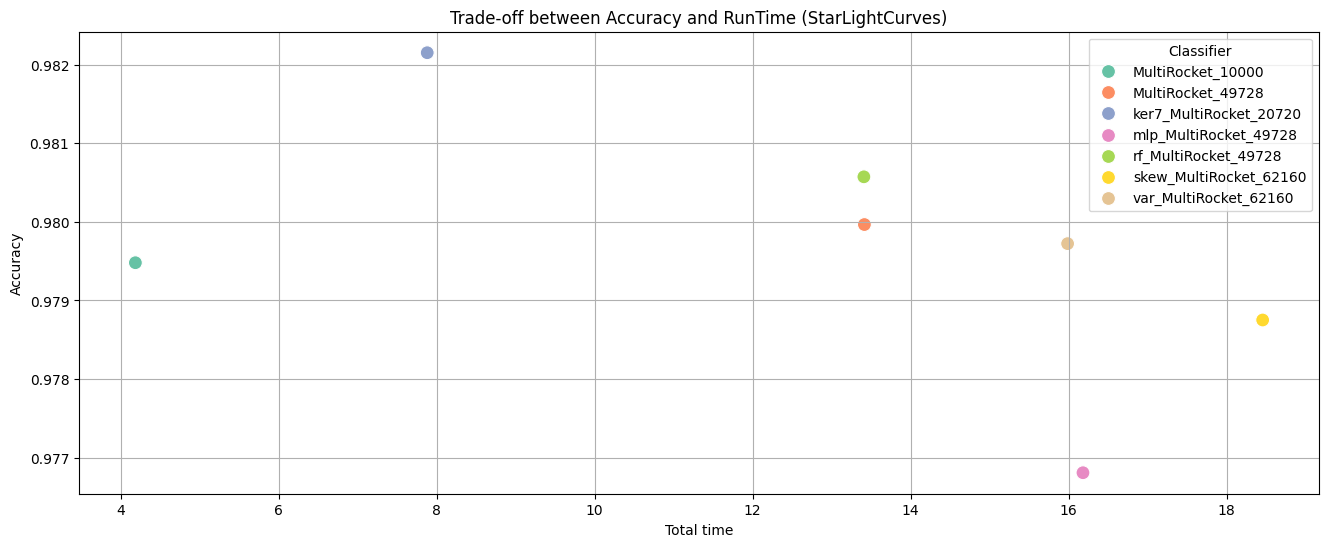

In [137]:
for i, dataset in enumerate(df['dataset'].unique()):
    
    plt.figure(figsize=(16, 6))

    #plt.subplot(2, 2, i+1)

    sns.scatterplot(data=df[df['dataset'] == dataset], x='total_time', y='test_acc', s=100, hue='classifier', palette='Set2')

    plt.title(f"Trade-off between Accuracy and RunTime ({dataset})")
    plt.xlabel("Total time")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend(loc='upper right', title='Classifier')

In [148]:
df_rank = df.copy()
df_rank['rank'] = df.groupby('dataset')['test_acc'].rank(ascending=False, method='min').astype(int)
# df_rank[['dataset', 'classifier', 'test_acc', 'rank']].sort_values(['dataset', 'rank'])

In [149]:
df_pivot = df_rank.pivot(index='dataset', columns='classifier', values='test_acc') # rank
# df_pivot

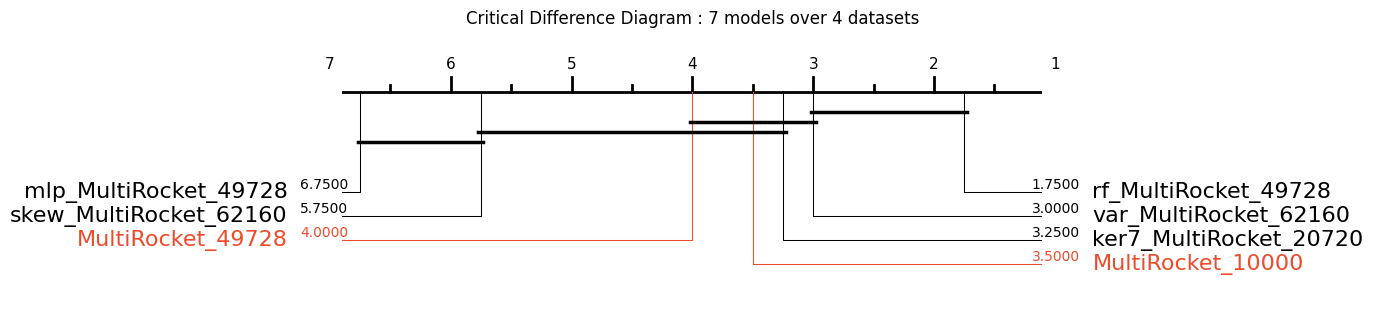

In [ ]:
results = df_pivot.values  # shape (n_datasets, n_classifiers)
methods = df_pivot.columns.tolist()

cdd = plot_critical_difference(results, methods,
                                highlight={"MultiRocket_10000":"#EE4B2B", "MultiRocket_49728":"#EE4B2B"},
                                lower_better=False,
                                test='wilcoxon', correction='holm', width=7,
                                textspace=0.6, reverse=True, alpha=1, return_p_values=True)

plt.title("Critical Difference Diagram : 7 models over 4 datasets")
plt.show()

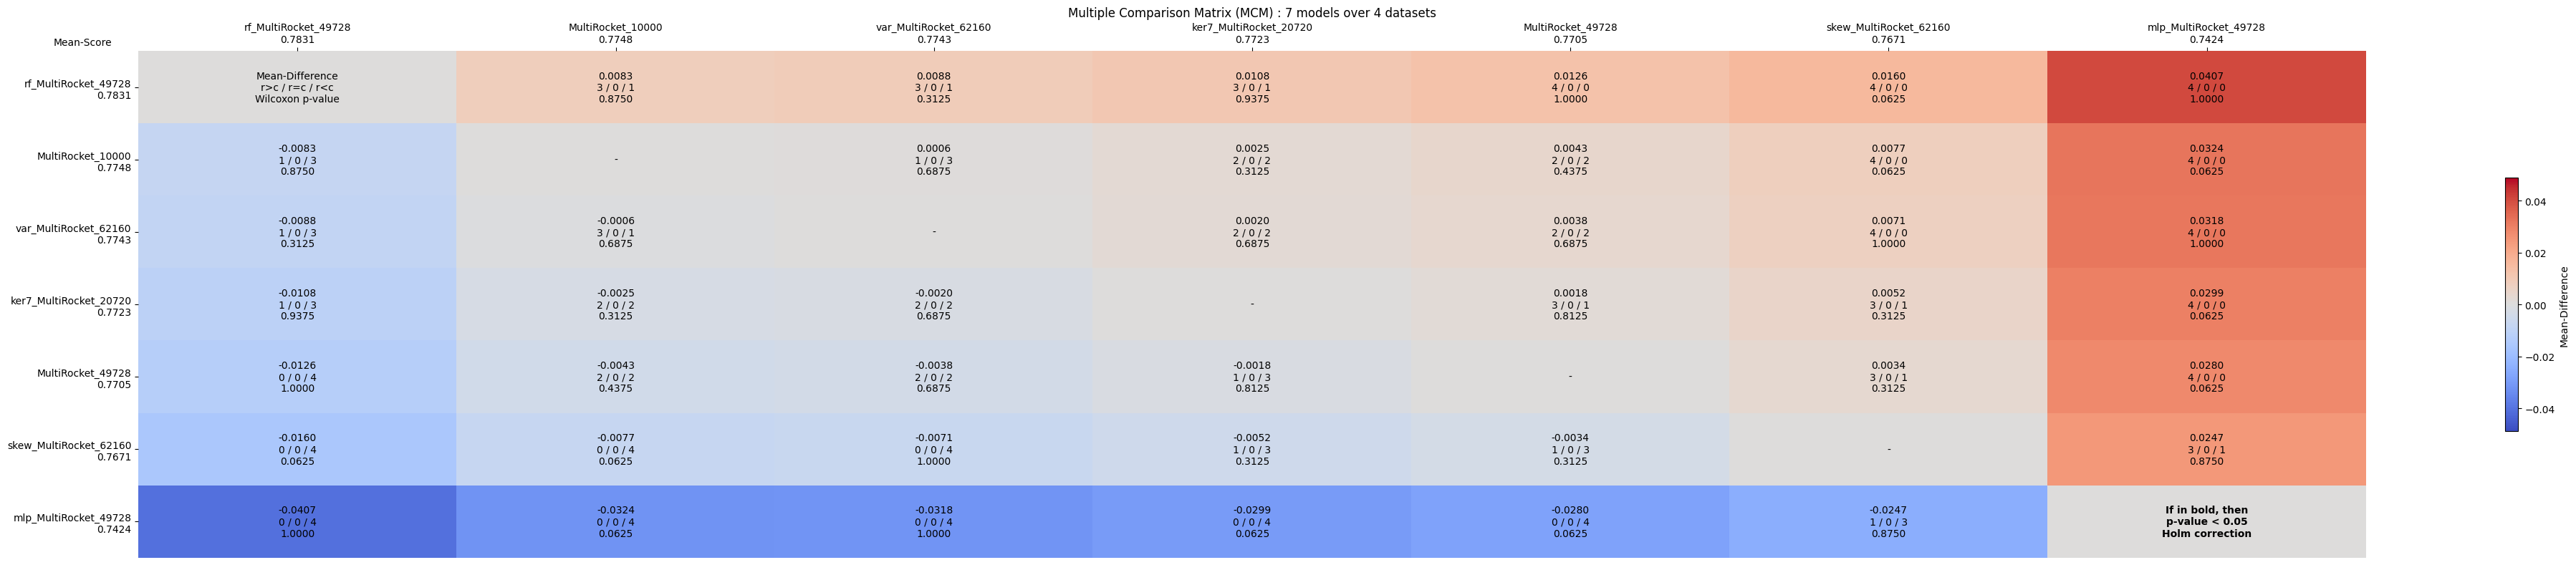

In [141]:
mcm = create_multi_comparison_matrix(df_pivot, pvalue_test='wilcoxon', pvalue_correction='Holm')

plt.title("Multiple Comparison Matrix (MCM) : 7 models over 4 datasets")
plt.show()

### 4.1 Synthesis and Conclusion

Across the two datasets for which complete multi-variant coverage exists,
`InsectWingbeatSound` and `StarLightCurves`, none of the three proposed
improvements delivers a consistent, meaningful gain in test accuracy over
the canonical MultiRocket baseline. The absolute accuracy deltas are small
in all cases, and the direction of the change is not uniform: the RF variant
improves marginally on `InsectWingbeatSound` whilst slightly underperforming
on `StarLightCurves`, and the remaining variants broadly follow a similar
pattern of near-parity with the baseline. This is consistent with the
published characterisation of MultiRocket, in which the linear ridge
regression head has been shown to be well-suited to the high-dimensional,
approximately Gaussian feature distributions produced by the convolutional
transform.

Of the three improvements, the kernel-size reduction from 9 to 7 (Ker7)
presents the most defensible accuracy-efficiency trade-off: it reduces the
feature count by 58.3% and the associated runtime, whilst preserving
accuracy within noise-level margins on both tested datasets. The fifth-pooling
operator variants (Var and Skew) impose an additional computational cost
proportional to the expanded feature representation without demonstrating a
corresponding accuracy benefit. The classifier substitution variants (MLP and
RF) increase training time, and the RF head introduces a substantial runtime
penalty on larger datasets, as evidenced by the supplementary results for
`ElectricDevices` (75.21 seconds) and `Crop` (44.56 seconds).

The principal limitation of these findings is the restricted experimental
scope. Results for `ElectricDevices` and `Crop` are available only for the RF
variant and only from a single supplementary run, precluding baseline
comparisons on those datasets. The entire study rests on a single experimental
resample (`resample_0`), whereas the original MultiRocket evaluation reports
accuracy averaged over thirty resamples. Single-resample estimates carry
meaningful variance, particularly on smaller datasets such as
`InsectWingbeatSound` with its 220 training instances. Running the full
complement of experiments including baseline runs on `ElectricDevices` and
`Crop`, across multiple resamples, would be necessary to support firm
conclusions about any of the proposed improvements.